# Car DJ project
## Image recognition system

In [ ]:
#!pip install fer

In [16]:
from fer.fer import FER
import cv2
import numpy as np

# Initialize detector once (reuse for all calls)
detector = FER(mtcnn=False)  # I disabled MTCNN bc I use Python 3.12 (not compatible)

def get_emotions(img_path):

    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Image not found: {img_path}")
    

    results = detector.detect_emotions(img)
    
    if not results:
        return np.array([0, 0, 0, 0])
    
    # Takes the first face
    em = results[0]["emotions"]
    
    # Maps it to 4-class array
    fixed_order = ["happy", "neutral", "angry", "sad"]
    emotions_array = np.array([em[e] for e in fixed_order])

    return emotions_array

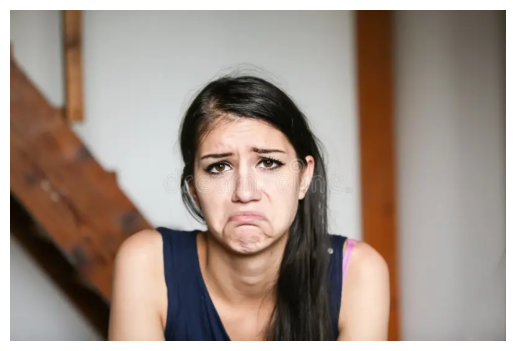

array([0.  , 0.  , 0.12, 0.82])

In [17]:
# here I test it with ONE image to see if the array results make sense
from matplotlib import pyplot as plt
image_path = "./sad2.jpg"
show_image = cv2.imread(image_path)
show_image = cv2.cvtColor(show_image, cv2.COLOR_BGR2RGB) 
plt.imshow(show_image)
plt.axis('off')
plt.show()
emotion_array = get_emotions(image_path)
emotion_array

### gets an image every 10s:

In [13]:
import cv2
import os
import time
import random
import numpy as np
from fer.fer import FER

detector = FER(mtcnn=False)  

def get_emotions_from_array_multi(img_array: np.ndarray) -> list:
    if img_array is None or img_array.size == 0:
        return []

    results = detector.detect_emotions(img_array)
    if not results:
        return []

    emotion_arrays = []
    fixed_order = ["happy", "neutral", "angry", "sad"]

    for res in results:
        em = res["emotions"]
        emotions_array = np.array([em[e] for e in fixed_order])
        if emotions_array.sum() > 0:
            emotions_array = emotions_array / emotions_array.sum()
        emotion_arrays.append(emotions_array)

    return emotion_arrays

# Path to images dataset folder
dataset_folder = "./dataset/images"
image_files = [f for f in os.listdir(dataset_folder) if f.lower().endswith(".jpg")]

# Loop --> pick a random image every 10 seconds (to change when putting all the code together)
max_duration = 60  # stop after 1 minute (this is for testing, remove or change after)
start_time = time.time()

while time.time() - start_time < max_duration:
    img_file = random.choice(image_files)  # pick a random image
    img_path = os.path.join(dataset_folder, img_file)
    img_array = cv2.imread(img_path)
    
    if img_array is None:
        print(f"Failed to load {img_file}, skipping...")
        continue
    
    # Detect emotions
    emotions_per_face = get_emotions_from_array_multi(img_array)
    
    if emotions_per_face:
        for i, em in enumerate(emotions_per_face):
            print(f"{img_file} - Face {i+1}: {em}")
    else:
        print(f"{img_file} - No faces detected")
    
    print("--- Waiting 10 seconds for next image ---\n")
    time.sleep(10)

enjoying-the-sun.jpg - Face 1: [1. 0. 0. 0.]
--- Waiting 10 seconds for next image ---

bullied.jpg - Face 1: [0.         0.79381443 0.16494845 0.04123711]
bullied.jpg - Face 2: [0.07446809 0.31914894 0.30851064 0.29787234]
bullied.jpg - Face 3: [0.25263158 0.07368421 0.23157895 0.44210526]
--- Waiting 10 seconds for next image ---

by-the-sea.jpg - Face 1: [0.1443299  0.1443299  0.07216495 0.63917526]
by-the-sea.jpg - Face 2: [0.03225806 0.52688172 0.07526882 0.3655914 ]
--- Waiting 10 seconds for next image ---

claws.jpg - Face 1: [0. 0. 1. 0.]
claws.jpg - Face 2: [0.16666667 0.44444444 0.12222222 0.26666667]
--- Waiting 10 seconds for next image ---

pain.jpg - No faces detected
--- Waiting 10 seconds for next image ---

bullied.jpg - Face 1: [0.         0.79381443 0.16494845 0.04123711]
bullied.jpg - Face 2: [0.07446809 0.31914894 0.30851064 0.29787234]
bullied.jpg - Face 3: [0.25263158 0.07368421 0.23157895 0.44210526]
--- Waiting 10 seconds for next image ---

